# Data analyse and video creation

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from numpy.polynomial import legendre

import pyvista as pv

In [15]:
file_path = 'target_state_amr2_rad1.h5'
variable_index = 5

with h5py.File(file_path, 'r') as f:
    time_keys = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
    first_dataset = f[time_keys[0]][()]
    nx, ny, _ = first_dataset.shape

grid = pv.ImageData(dimensions=(nx, ny, 1))

plotter = pv.Plotter(off_screen=True)
plotter.open_movie('compression_plasma_2D.mp4', framerate=10)

# Transparency curve: 0.0 corresponds to the black background, 1.0 corresponds to bright colors
opacity_curve = [0.0, 0.05, 0.4, 1.0]

with h5py.File(file_path, 'r') as f:
    initial_data = f[time_keys[0]][()][:, :, variable_index]
    grid.point_data["Density"] = initial_data.flatten(order="F")
    
    # Using add_mesh with the opacity argument to create the halo effect
    actor = plotter.add_mesh(
        grid,
        scalars="Density",
        cmap="inferno",
        opacity=opacity_curve,
        show_scalar_bar=True
    )
    
    plotter.camera_position = 'xy'
    plotter.set_background('black')
    
    for key_name in time_keys:
        data = f[key_name][()][:, :, variable_index]
        
        # Updating values to recalculate colors and opacity
        plotter.update_scalars(data.flatten(order="F"), render=False)
        
        plotter.write_frame()

plotter.close()

C:\Users\clara\AppData\Local\Temp\ipykernel_24368\3942460724.py:37: PyVistaDeprecationWarning: This method is deprecated and will be removed in a future version of PyVista. Directly modify the scalars of a mesh in-place instead.
  plotter.update_scalars(data.flatten(order="F"), render=False)


## Uniformity analyse with spherical harmonics

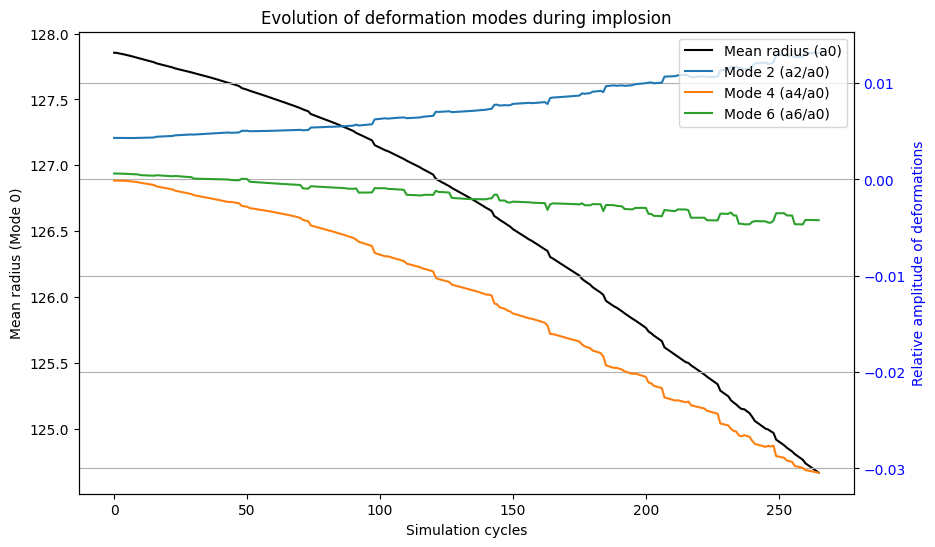

In [16]:
file_path = 'target_state_amr2_rad1.h5'
variable_index = 5

# Calibrated parameters for the target shell
density_threshold = 709.0 
max_degree = 6

time_history = []
coeffs_history = {i: [] for i in range(max_degree + 1)}

with h5py.File(file_path, 'r') as f:
    time_keys = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
    
    # Getting dimensions to define the actual center (bottom right corner)
    first_dataset = f[time_keys[0]][()]
    nx, ny, _ = first_dataset.shape
    center_x, center_y = nx, 0
    
    for idx, key_name in enumerate(time_keys):
        data = f[key_name][()][:, :, variable_index]
        
        # 1. Contour extraction
        contours = measure.find_contours(data, density_threshold)
        
        if not contours:
            continue
            
        main_contour = max(contours, key=len)
        
        # 2. Coordinate centering (skimage returns [row, column], i.e., [Y, X])
        raw_y = main_contour[:, 0] - center_y
        raw_x = main_contour[:, 1] - center_x
        
        # 3. Mirror symmetry to recreate the full semi-circle
        full_x = np.concatenate([raw_x, -raw_x])
        full_y = np.concatenate([raw_y, raw_y])
        
        # Conversion to polar coordinates
        radii = np.sqrt(full_x**2 + full_y**2)
        theta_angles = np.arctan2(full_y, full_x)
        
        # 4. Legendre polynomial decomposition over the full interval
        cos_theta = np.cos(theta_angles)
        coeffs = legendre.legfit(cos_theta, radii, deg=max_degree)
        
        # Saving results
        time_history.append(idx)
        for l in range(max_degree + 1):
            coeffs_history[l].append(coeffs[l])

# 5. Displaying results
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Simulation cycles')
ax1.set_ylabel('Mean radius (Mode 0)', color='black')
ax1.plot(time_history, coeffs_history[0], color='black', label='Mean radius (a0)')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.set_ylabel('Relative amplitude of deformations', color='blue')

# Plotting even deformation modes
for l in [2, 4, 6]: 
    relative_amplitude = np.array(coeffs_history[l]) / np.array(coeffs_history[0])
    ax2.plot(time_history, relative_amplitude, label=f'Mode {l} (a{l}/a0)')

ax2.tick_params(axis='y', labelcolor='blue')
plt.title("Evolution of deformation modes during implosion")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.grid(True)
plt.show()

## Density analize

In [ ]:
import h5py
import numpy as np
import pandas as pd

chemin_fichier = 'target_state_amr2_rad1.h5'
indice_variable_dt = 5  # À ajuster selon l'indice exact du DT dans ta simulation

historique_temps = []
historique_densite_dt = []

with h5py.File(chemin_fichier, 'r') as f:
    # On réutilise ta méthode de tri pour avoir les cycles dans l'ordre chronologique
    cles_temps = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
    
    for nom_cle in cles_temps:
        dataset = f[nom_cle]
        
        # 1. Extraction de la coordonnée temporelle
        # Dans ARWEN, le temps physique réel est généralement stocké en attribut
        if 'time' in dataset.attrs:
            t = dataset.attrs['time']
        else:
            # Si l'attribut n'y est pas, on extrait le numéro du cycle depuis le nom de la clé
            t = float(nom_cle.split('cy')[-1])
            
        historique_temps.append(t)
        
        # 2. Extraction du maillage 2D pour ce pas de temps précis
        donnees_spatiales = dataset[()][:, :, indice_variable_dt]
        
        # 3. Somme spatiale de la densité (intégration sur le domaine) pour obtenir la valeur totale
        densite_totale = np.sum(donnees_spatiales)
        historique_densite_dt.append(densite_totale)

# On structure les données dans un DataFrame pandas pour obtenir un format "tableau"
df_arwen = pd.DataFrame({
    'Temps': historique_temps,
    'Densite_DT_Totale': historique_densite_dt
})

print("Étape 1 terminée. Voici l'en-tête du tableau extrait :")
print(df_arwen.head())

In [ ]:
# Calcul vectoriel de l'incrément de temps entre chaque cycle
df_arwen['Delta_t'] = df_arwen['Temps'].diff().fillna(0.0)

# Affichage du tableau mis à jour pour vérification
print("Étape 2 terminée. Tableau avec les incréments de temps (Delta_t) :")
print(df_arwen.head())

In [ ]:
# Étape 3 : Multiplication de la densité par le pas de temps (produit vectoriel)
df_arwen['Produit_X_Dt'] = df_arwen['Densite_DT_Totale'] * df_arwen['Delta_t']

# Étape 4 : Calcul de la somme totale sur toute la simulation
somme_totale_densite = df_arwen['Produit_X_Dt'].sum()

# Optionnel : Calcul de la somme cumulée au cours du temps (utile pour un graphique)
df_arwen['Densite_Cumulee'] = df_arwen['Produit_X_Dt'].cumsum()

# Affichage des résultats
print(f"Résultat final de l'intégrale (Densité totale intégrée) : {somme_totale_densite:.5e}")
print("\nTableau final avec la somme cumulée :")
print(df_arwen[['Temps', 'Densite_DT_Totale', 'Delta_t', 'Densite_Cumulee']].head())